In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [7]:
import numpy as np
import pandas as pd # get_dummies
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.datasets import mnist # mnist 데이터 셋 => 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.layers import Dense, Input, Dropout
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # 이미지 파일은 0 ~ 255의 값을 갖으므로 scaler 대신 값/255 사용
from sklearn.model_selection import train_test_split # 데이터 분리

In [8]:
# 1. 데이터 셋
width = 28 ; height = 28
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [6]:
# 코랩 시각화용 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (6,916 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and dire

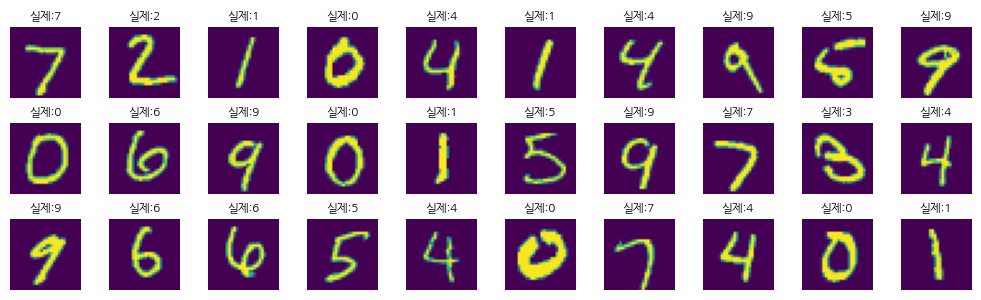

In [6]:
plt_row = 3
plt_col = 10
# plt.figure(figsize=(plt_col,plt_row))
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
# plt.rc('font', family = 'Malgun Gothic', size = 7) # 한글시각화용
plt.rc('font', family='NanumGothic') # 코랩 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
# axes[0,0].imshow(X_test[0].reshape(width, height))
# axes[0,0].axis('off')
# title = '실제:{}'.format(y_test[0])
# axes[0,0].set_title(title)
# plt.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(plt_col*plt_row) :
    x = i//plt_col ; y = i%plt_col
    axes[x,y].imshow(X_test[i].reshape(width, height))
    axes[x,y].axis('off')
    title = '실제:{}'.format(y_test[i])
    axes[x,y].set_title(title)
plt.tight_layout()

# 1. DNN

In [ ]:
%%time
# 1. 데이터 생성 및 전처리
width,height = 28,28
(X_train, y_train), (X_test,y_test) = mnist.load_data()
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 독립변수 28,28 => 784 1차원 -> 실수형으로 변환 -> 스케일 조정
X_train = X_train.reshape(-1,width*height).astype(np.float32)/255.0
X_val = X_val.reshape(-1,width*height).astype(np.float32)/255.0
X_test = X_test.reshape(-1,width*height).astype(np.float32)/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

X_train.shape, Y_train.shape, X_val.shape, Y_val.shape,X_test.shape, Y_test.shape

# 2. 모델 구성
model = Sequential([
    Input(width*height),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax'),
])
# model.summary()
# 3. 학습설정
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics=['accuracy'])
model.fit(X_train, Y_train, epochs=50, validation_data=(X_val,Y_val))
# 노트북 환경에서 실행시키면 1h 45min이 걸려서 colab으로 학습하는게...

Epoch 1/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.2710 - accuracy: 0.9172 - val_loss: 0.1182 - val_accuracy: 0.9662
Epoch 2/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.1406 - accuracy: 0.9583 - val_loss: 0.1084 - val_accuracy: 0.9687
Epoch 3/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.1112 - accuracy: 0.9674 - val_loss: 0.0936 - val_accuracy: 0.9739
Epoch 4/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0960 - accuracy: 0.9716 - val_loss: 0.0884 - val_accuracy: 0.9751
Epoch 5/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0825 - accuracy: 0.9754 - val_loss: 0.1175 - val_accuracy: 0.9686
Epoch 6/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0755 - accuracy: 0.9784 - val_loss: 0.0907 - val_accuracy: 0.9753
Epoch 7/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0689 - accuracy: 0.9799 - val_loss: 0.0910 -

In [ ]:
model.evaluate(X_test,Y_test) # 정확도 98.33%

313/313 [==============================] - 1s 4ms/step - loss: 0.1734 - accuracy: 0.9833


[0.1734016090631485, 0.983299970626831]

In [ ]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
print('실제값 :',y_test) # 실제값
# y_hat = model.predict(X_test)
print('예측값 :',y_hat.argmax(axis=1))
cmatrix = confusion_matrix(y_test, y_hat.argmax(axis=1))
print(cmatrix)

실제값 : [7 2 1 ... 4 5 6]
예측값 : [7 2 1 ... 4 5 6]
[[ 972    0    0    1    0    1    3    1    2    0]
 [   0 1123    3    0    0    1    6    0    2    0]
 [   1    1 1018    2    1    0    2    3    4    0]
 [   0    0    2  998    0    3    0    3    3    1]
 [   0    1    1    0  965    0    4    0    1   10]
 [   1    0    0    8    1  869    4    1    5    3]
 [   2    2    0    0    1    3  949    0    1    0]
 [   2    2    5    2    0    0    0 1010    4    3]
 [   3    1    3    4    3    5    1    2  951    1]
 [   2    2    0    6    8    4    1    4    4  978]]


In [ ]:
# 실제값과 예측값이 다른 개수 방법 1.
cnt = 0
for i, row in enumerate(cmatrix) :
    for j, data in enumerate(row) :
        if i != j :
            cnt += data
print('예측이 틀린 개수 :',cnt)

예측이 틀린 개수 : 167


In [ ]:
# 실제값과 예측값이 다른 개수 방법 2.
cnt = 0
for y, h in zip(y_test, y_hat.argmax(axis=1)) :
    if y!= h :
        cnt +=1
print('예측이 틀린 개수 :',cnt)

예측이 틀린 개수 : 167


In [ ]:
# CNN을 사용하여 예측이 틀린 데이터 출력(y_hat과 y_test가 다른 것들 167개 출력)

167

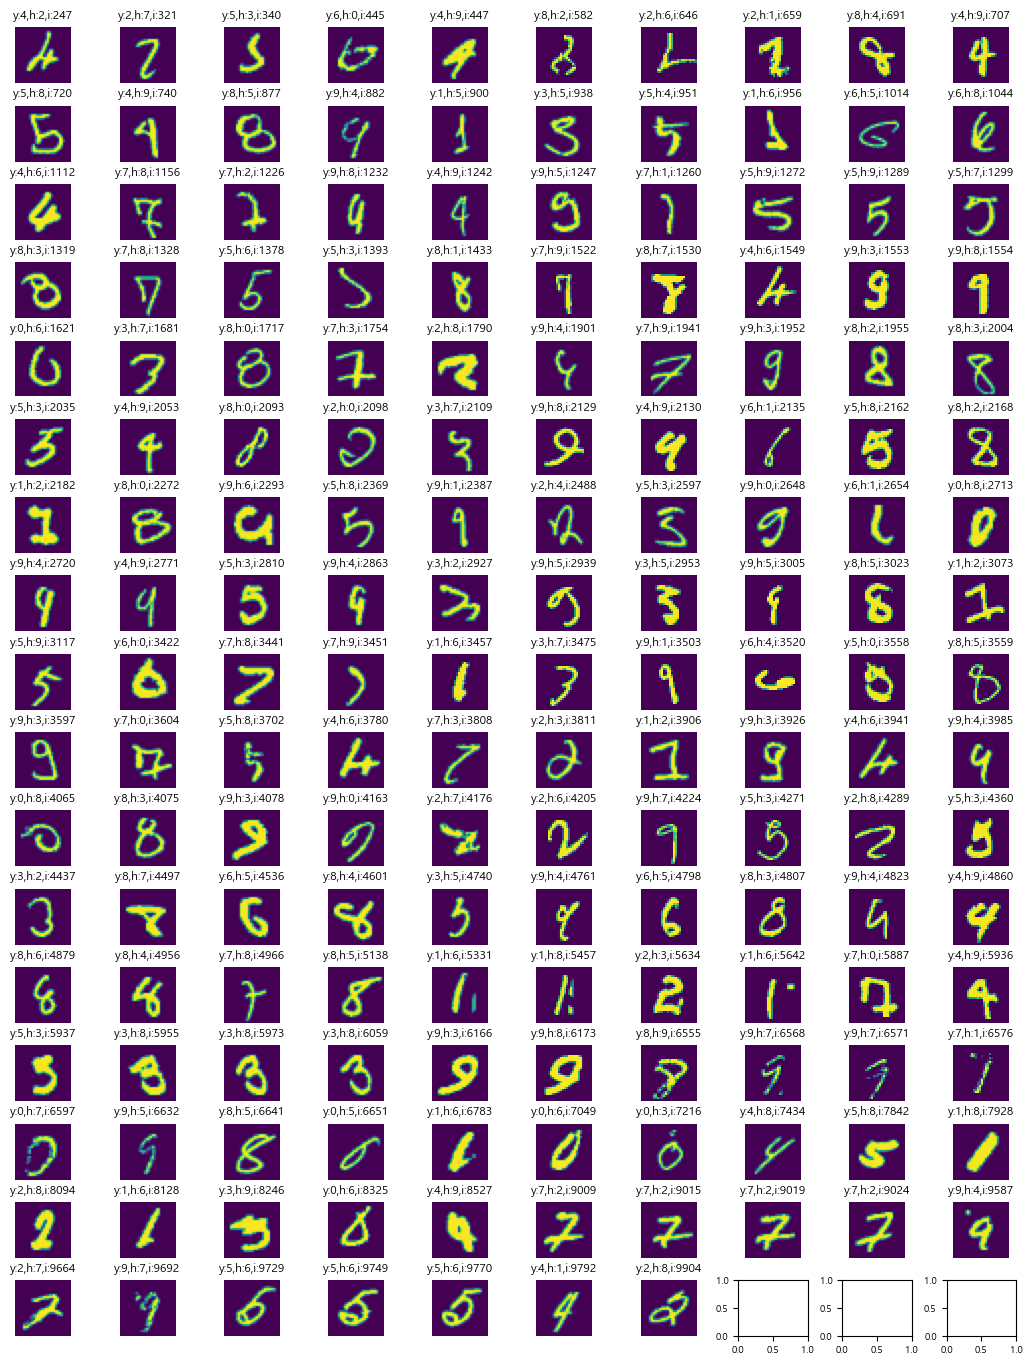

In [ ]:
# DNN을 사용하여 예측이 틀린 데이터 출력(y_hat과 y_test가 다른 것들 167개 출력)
plt_row = 17
plt_col = 10
# plt.figure(figsize=(plt_col,plt_row))
plt.rcParams['figure.figsize'] = [plt_col+3, plt_row] # 이게 figsize가 더 크게 잡히네..?
plt.rc('font', family='NanumGothic') # 코랩 한글 시각화 # 한글시각화용
# plt.rc('font', family = 'NanumBarumGothic') # 코랩 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.4, wspace=0.5)
i = 0 # y_hat과 y_test의 index => y_hat[i], y_test[i] 비교
cnt = 0 # 이미지 출력회수
while i < len(y_test) and cnt < plt_row*plt_col :
    if  y_test[i] != y_hat.argmax(axis=1)[i] :
        x = cnt//plt_col ; y = cnt%plt_col
        axes[x,y].imshow(X_test[i].reshape(width, height))
        axes[x,y].axis('off')
        title = 'y:{},h:{},i:{}'.format(y_test[i], y_hat.argmax(axis=1)[i], i)
        axes[x,y].set_title(title)
        cnt +=1 # 이미지 출력 번호 증가
    i +=1 # 인덱스 증가

# 2. CNN(컨볼루션 레이어 포함)
- 딥러닝 자료 31page

In [9]:
plt.rc('font', family = 'NanumBarunGothic') # 코랩 한글 시각화

In [12]:
%%time
# 1. 데이터 생성 및 전처리
width,height = 28,28
(X_train, y_train), (X_test,y_test) = mnist.load_data()
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 독립변수 28,28 => 784 1차원 -> 실수형으로 변환 -> 스케일 조정
X_train = X_train.reshape(-1,width,height,1).astype(np.float32)/255.0
X_val = X_val.reshape(-1,width,height,1).astype(np.float32)/255.0
X_test = X_test.reshape(-1,width,height,1).astype(np.float32)/255.0
# # 타겟변수 원핫인코딩
# Y_train = to_categorical(y_train)
# Y_val = to_categorical(y_val)
# Y_test = to_categorical(y_test)

X_train.shape, y_train.shape, X_val.shape, y_val.shape,X_test.shape, y_test.shape

CPU times: user 391 ms, sys: 92.5 ms, total: 484 ms
Wall time: 636 ms


((50000, 28, 28, 1),
 (50000,),
 (10000, 28, 28, 1),
 (10000,),
 (10000, 28, 28, 1),
 (10000,))

In [19]:
# 2. 모델 생성
# 자습1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.datasets import mnist
# CNN 필요 라이브러리
from tensorflow.keras.layers import Conv2D  # Conv2D : Convolution층
from tensorflow.keras.layers import MaxPooling2D  # MaxPooling2D : pooling층
from tensorflow.keras.layers import Flatten # Flatten : 2D의 그림을 DNN에 올리기 위해 1D화
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 자습2
model = Sequential([
    # 첫 번째 합성곱 층: 32개의 필터, 커널 크기 3x3, ReLU 활성화 함수 사용
    Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2,2)),  # 최대 풀링으로 특성 맵 크기 감소

    # 두 번째 합성곱 층: 64개의 필터 적용
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),  # 2D 데이터를 1D 벡터로 변환하여 Dense 층에 전달
    Dense(128, activation='relu'),  # 완전 연결층
    Dense(10, activation='softmax')  # 출력층 (0~9 숫자 분류, softmax 사용)
])

# 모델 컴파일 (손실 함수, 옵티마이저, 평가 지표 설정)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # 다중 클래스 분류 문제
              metrics=['accuracy'])  # 정확도를 측정
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 자습3

# 모델 학습 (훈련 데이터로 5 에포크 동안 학습)
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# 모델 평가 (테스트 데이터로 성능 확인)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"테스트 정확도: {test_acc:.4f}")  # 학습된 모델의 성능 출력

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8981 - loss: 0.3258 - val_accuracy: 0.9841 - val_loss: 0.0498
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9863 - loss: 0.0455 - val_accuracy: 0.9875 - val_loss: 0.0366
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 0.9906 - val_loss: 0.0288
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9935 - loss: 0.0198 - val_accuracy: 0.9888 - val_loss: 0.0327
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9952 - loss: 0.0140 - val_accuracy: 0.9896 - val_loss: 0.0310
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9865 - loss: 0.0379
테스트 정확도: 0.9896


In [ ]:
# 자습4
y_hat = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
# 자습5
len(y_test[y_test != y_hat.argmax(axis=1)])

104

In [29]:
# 2. 모델 생성
model = Sequential()
model.add(Conv2D(filters=32, # 필터(커널) 수
                 kernel_size=(3,3), # 필터(커널)의 크기 -> int 3도 가능하고 (3,3)도 가능 => 일반적으로 커널의 크기는 정사각형 형태
                 activation='relu',
                 padding="same", # 입력값과 같은 크기(28x28)로 반환하기 위해 제로패딩(zero-padding)
                 input_shape=(width, height, 1), # input_shape = (width, height, channel) 입력채녈 1개, 필터 32 => 28*28*32채널 출력
                 ))
model.add(MaxPooling2D(pool_size=(2,2))) # int 2 도 가능 // 14*14*32채널
model.add(Dropout(0.1))
model.add(Conv2D(filters=64, # 필터(커널) 수
                 kernel_size=(3,3), # 필터(커널)의 크기 -> int 3도 가능하고 (3,3)도 가능 => 일반적으로 커널의 크기는 정사각형 형태
                 activation='relu',
                 )) # return size = ((14-3+1)*(14-3+1)*32) * 64
model.add(MaxPooling2D(pool_size=(2,2))) # (6*6*32)*64
model.add(Dropout(0.25))
model.add(Flatten()) # 입력을 1차원으로
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))
model.summary()
# 320 => 3x3 필터가 weight / bias 1개  => ((3*3)+1)*32(필터개수) => 320파라미터
# 18496 => 3x3 필터가 weight ((3*3*32)+1bias)*64 => 18,496파라미터
# flatten_1 => 2304 (6*6*64)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,146 (1.20 MB)

 Trainable params: 315,146 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# 3. 모델 학습과정 설정
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics=['accuracy'])

In [31]:
# 4. 모델 학습 => 코랩에서 활용(GPU가 없으므로)
earlystopping = EarlyStopping(patience=20)
hist = model.fit(X_train,y_train,validation_split=0.2, epochs=500, batch_size=128, callbacks=[earlystopping])

Epoch 1/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7458 - loss: 0.7763 - val_accuracy: 0.9692 - val_loss: 0.1058
Epoch 2/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9562 - loss: 0.1436 - val_accuracy: 0.9730 - val_loss: 0.0817
Epoch 3/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9681 - loss: 0.1055 - val_accuracy: 0.9804 - val_loss: 0.0602
Epoch 4/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9731 - loss: 0.0852 - val_accuracy: 0.9824 - val_loss: 0.0547
Epoch 5/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9789 - loss: 0.0719 - val_accuracy: 0.9836 - val_loss: 0.0505
Epoch 6/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9821 - loss: 0.0606 - val_accuracy: 0.9845 - val_loss: 0.0464
Epoch 7/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9819 - loss: 0.0575 - val_accuracy: 0.9856 - val_loss: 0.0457
Epoch 8/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9825 - loss: 0.0553 - val_ac

In [27]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

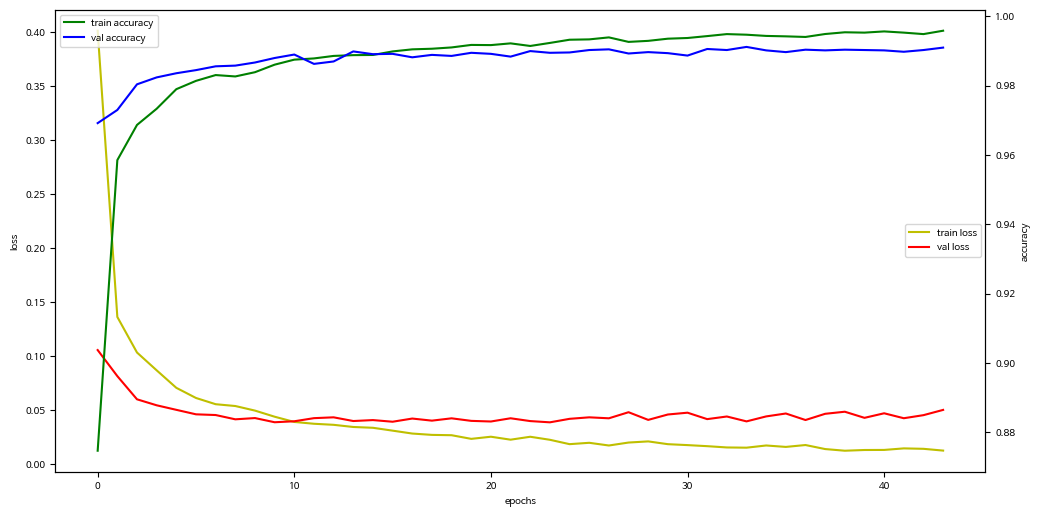

In [32]:
# 5. 모델 학습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend(loc='upper left')
plt.show()

In [35]:
# 6. 모델 평가
loss, acc = model.evaluate(X_test,y_test)
print('loss :',loss)
print('accuracy :',acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9912 - loss: 0.0345
loss : 0.029263880103826523
accuracy : 0.9927999973297119


In [37]:
real = y_test
pred = model.predict(X_test).argmax(axis=1)
print('실제 값 :',y_test)
print('예측 값 :',pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
실제 값 : [7 2 1 ... 4 5 6]
예측 값 : [7 2 1 ... 4 5 6]


In [38]:
# 실제값과 예측값이 다른 개수 방법
cnt = 0
for y, h in zip(real, pred) :
    if y!= h :
        cnt +=1
print('예측이 틀린 개수 :',cnt)

예측이 틀린 개수 : 72


In [40]:
# 교차표
cmatrix = confusion_matrix(real, pred)
print(cmatrix)

[[ 976    0    1    0    0    0    2    1    0    0]
 [   0 1133    1    0    0    0    1    0    0    0]
 [   1    1 1028    0    1    0    0    1    0    0]
 [   0    0    2 1006    0    1    0    0    1    0]
 [   0    0    0    0  976    0    0    0    2    4]
 [   1    0    0    7    0  882    2    0    0    0]
 [   3    3    0    0    1    1  949    0    1    0]
 [   0    1    6    1    1    0    0 1018    0    1]
 [   3    0    2    1    0    0    0    0  966    2]
 [   0    2    0    0    6    1    0    4    2  994]]


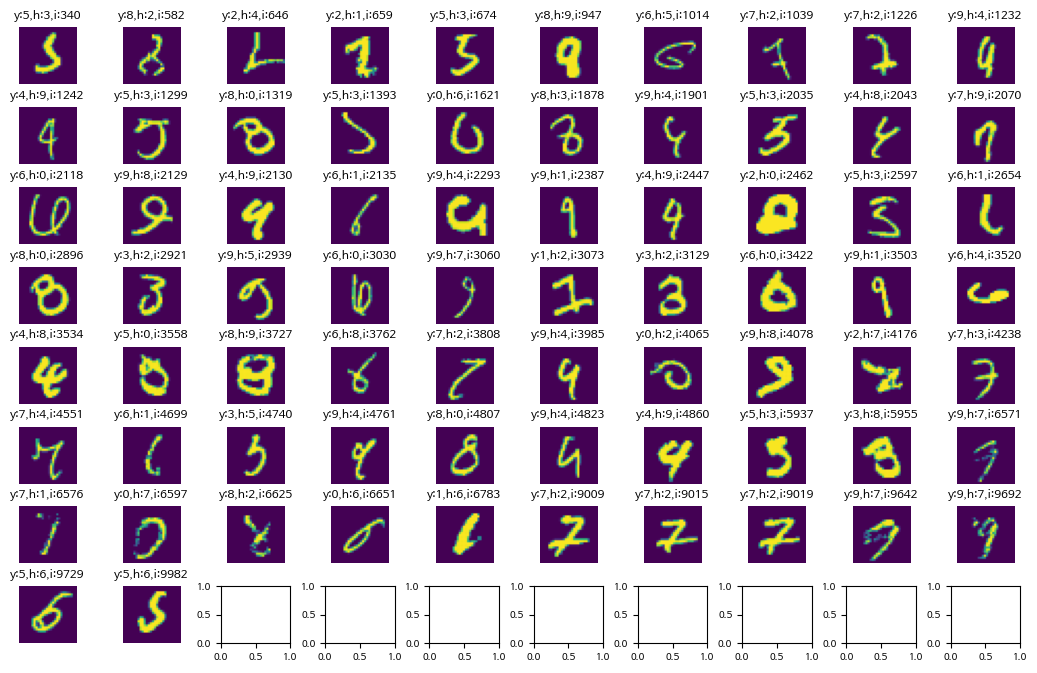

In [39]:
# CNN을 사용하여 예측이 틀린 데이터 출력(real과 pred가 다른 것들 72개 출력)
plt_row = 8
plt_col = 10
# plt.figure(figsize=(plt_col,plt_row))
plt.rcParams['figure.figsize'] = [plt_col+3, plt_row] # 이게 figsize가 더 크게 잡히네..?
plt.rc('font', family = 'NanumBarunGothic') # 코랩 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.4, wspace=0.5)
i = 0 # y_hat과 y_test의 index => y_hat[i], y_test[i] 비교
cnt = 0 # 이미지 출력회수
while i < len(real) and cnt < plt_row*plt_col :
    if  real[i] != pred[i] :
        x = cnt//plt_col ; y = cnt%plt_col
        axes[x,y].imshow(X_test[i].reshape(width, height))
        axes[x,y].axis('off')
        title = 'y:{},h:{},i:{}'.format(real[i], pred[i], i)
        axes[x,y].set_title(title)
        cnt +=1 # 이미지 출력 번호 증가
    i +=1 # 인덱스 증가

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
save_model(model,'/content/drive/MyDrive/Colab Notebooks/0_mbc_academy/model/CNN.h5')